In [ ]:
!pip install pandas numpy nltk vaderSentiment matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd

reviews = pd.read_excel("Google_reviews.xlsx")
tweets = pd.read_excel("x_scraped_dataset.xlsx")

print(reviews.head())
print(tweets.head())

  Brand Name      Market Type Country Brand Origin                 Date  \
0      Tesco  Individualistic      UK        Local  2025-12-09 00:00:00   
1      Tesco  Individualistic      UK        Local  2025-12-08 00:00:00   
2      Tesco  Individualistic      UK        Local  2025-12-07 00:00:00   
3      Tesco  Individualistic      UK        Local  2025-12-03 00:00:00   
4      Tesco  Individualistic      UK        Local  2025-12-03 00:00:00   

       Reviwer_Name Rating                                 Review_description  
0  Richard Nicholls      3  Why are there never any baskets available anyw...  
1       terry jones      5           What you would expect from a superstore.  
2         Div Patel      1  Don't even Deserve one Star some staff are so ...  
3         Seyon Hos      5  Great Superstore for all your household needs ...  
4              Ella      1  I beg. Get some more baskets. Every time I com...  
  Country Brand_Origin Retailer Source_Platform              Post_ID 

In [ ]:

reviews = reviews.rename(columns={
    "Review_description": "Text",
    "Brand Name": "Brand",
    "Brand Origin": "Origin"
})


reviews = reviews[["Brand", "Origin", "Country", "Date", "Rating", "Text"]]

# Add platform column
reviews["Platform"] = "Google"

# Clean text
reviews["Text"] = reviews["Text"].str.lower()

reviews = reviews.dropna(subset=["Text"])

In [ ]:
print(tweets.columns.tolist())

['Country', 'Brand_Origin', 'Retailer', 'Source_Platform', 'Post_ID', 'Date', 'Author_ID_Anon', 'Engagement_Count', 'Text', 'Sentiment_VADER', 'Platform']


In [ ]:
# Clean X column names
tweets.columns = tweets.columns.str.strip()


tweets = tweets.rename(columns={
    "Retailer": "Brand",
    "Brand_Origin": "Origin"
})


tweets["Platform"] = "X"

# Remove retweets
tweets = tweets[~tweets["Text"].astype(str).str.contains(r"^RT @", na=False)]

# Remove links
tweets = tweets[~tweets["Text"].astype(str).str.contains("http", na=False)]

# Remove very short posts
tweets = tweets[tweets["Text"].astype(str).str.len() > 20]

# Keep only required columns
tweets = tweets[["Brand", "Origin", "Country", "Date", "Text", "Platform"]]

# Add rating column because X posts do not have ratings
tweets["Rating"] = None

# Check output
print(tweets.head())
print(tweets.shape)
print(tweets.columns.tolist())

   Brand Origin Country        Date  \
0  Tesco  Local      UK  2025-12-11   
1  Tesco  Local      UK  2025-12-11   
2  Tesco  Local      UK  2025-12-11   
4  Tesco  Local      UK  2025-12-11   
5  Tesco  Local      UK  2025-12-11   

                                                Text Platform Rating  
0  @GBNEWS @Nigel_Farage Plastic holiday trees fr...        X   None  
1  @David__Osland £7 for toothpaste, £5 for deodo...        X   None  
2  @DerbyChrisW @Keir_Starmer Stop with the negat...        X   None  
4  @absolutelyamyyy I work in the Tesco call cent...        X   None  
5  @JSHKT20 @PoliceChiefs @surreycricket @ICOnews...        X   None  
(121, 7)
['Brand', 'Origin', 'Country', 'Date', 'Text', 'Platform', 'Rating']


In [ ]:
reviews = reviews[["Brand", "Origin", "Country", "Date", "Rating", "Text", "Platform"]]
tweets  = tweets[["Brand", "Origin", "Country", "Date", "Rating", "Text", "Platform"]]

In [ ]:
data = pd.concat([reviews, tweets], ignore_index=True)

print(data.head())
print(data.shape)

   Brand Origin Country                 Date Rating  \
0  Tesco  Local      UK  2025-12-09 00:00:00      3   
1  Tesco  Local      UK  2025-12-08 00:00:00      5   
2  Tesco  Local      UK  2025-12-07 00:00:00      1   
3  Tesco  Local      UK  2025-12-03 00:00:00      5   
4  Tesco  Local      UK  2025-12-03 00:00:00      1   

                                                Text Platform  
0  why are there never any baskets available anyw...   Google  
1           what you would expect from a superstore.   Google  
2  don't even deserve one star some staff are so ...   Google  
3  great superstore for all your household needs ...   Google  
4  i beg. get some more baskets. every time i com...   Google  
(1268, 7)


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))["compound"]
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

data["Sentiment"] = data["Text"].apply(get_sentiment)

print(data["Sentiment"].value_counts())

Sentiment
Positive    777
Negative    339
Neutral     152
Name: count, dtype: int64


In [ ]:
print(reviews.columns.tolist())

['Brand', 'Origin', 'Country', 'Date', 'Rating', 'Text', 'Platform']


In [ ]:
print(data.shape)
print(data["Platform"].value_counts(dropna=False))
print(data[["Brand", "Platform"]].head(10))

(1268, 8)
Platform
Google    1147
X          121
Name: count, dtype: int64
   Brand Platform
0  Tesco   Google
1  Tesco   Google
2  Tesco   Google
3  Tesco   Google
4  Tesco   Google
5  Tesco   Google
6  Tesco   Google
7  Tesco   Google
8  Tesco   Google
9  Tesco   Google


In [ ]:
reviews = reviews[["Brand", "Origin", "Country", "Date", "Rating", "Text", "Platform"]]
tweets  = tweets[["Brand", "Origin", "Country", "Date", "Rating", "Text", "Platform"]]

# Merge
data = pd.concat([reviews, tweets], ignore_index=True)

# Check result
print(data.shape)
print(data["Platform"].value_counts(dropna=False))
print(data.head())

(1268, 7)
Platform
Google    1147
X          121
Name: count, dtype: int64
   Brand Origin Country                 Date Rating  \
0  Tesco  Local      UK  2025-12-09 00:00:00      3   
1  Tesco  Local      UK  2025-12-08 00:00:00      5   
2  Tesco  Local      UK  2025-12-07 00:00:00      1   
3  Tesco  Local      UK  2025-12-03 00:00:00      5   
4  Tesco  Local      UK  2025-12-03 00:00:00      1   

                                                Text Platform  
0  why are there never any baskets available anyw...   Google  
1           what you would expect from a superstore.   Google  
2  don't even deserve one star some staff are so ...   Google  
3  great superstore for all your household needs ...   Google  
4  i beg. get some more baskets. every time i com...   Google  


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))["compound"]
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

data["Sentiment"] = data["Text"].apply(get_sentiment)

print(data["Sentiment"].value_counts())

Sentiment
Positive    777
Negative    339
Neutral     152
Name: count, dtype: int64


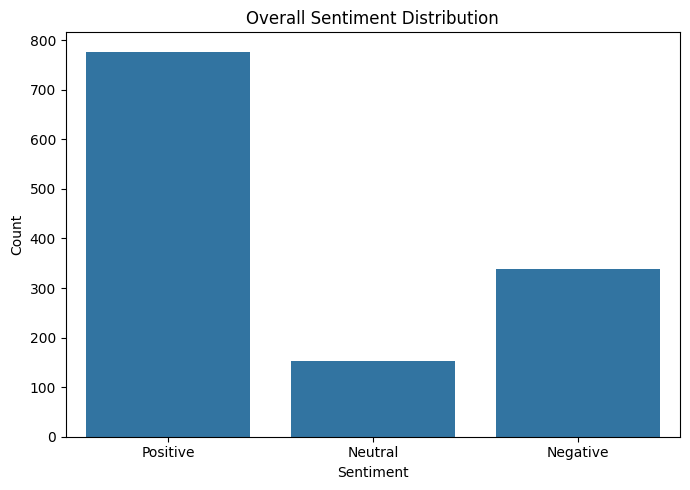

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.countplot(data=data, x="Sentiment", order=["Positive", "Neutral", "Negative"])
plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("overall_sentiment.png", dpi=300)
plt.show()

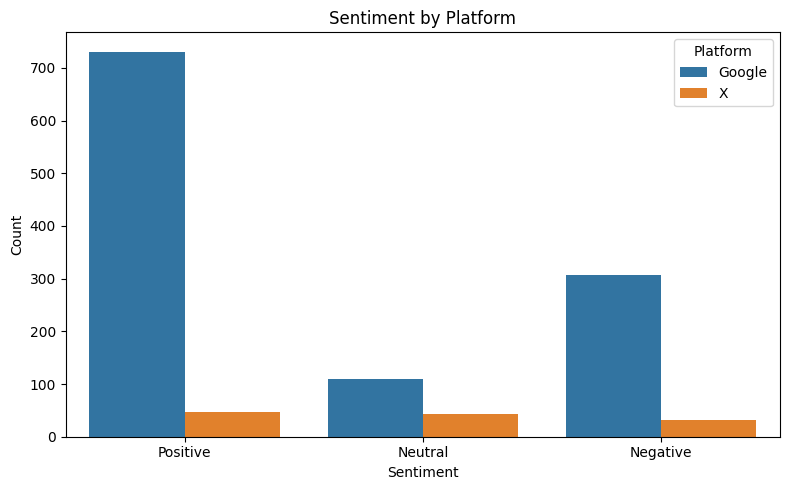

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=data, x="Sentiment", hue="Platform", order=["Positive", "Neutral", "Negative"])
plt.title("Sentiment by Platform")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("sentiment_by_platform.png", dpi=300)
plt.show()

In [ ]:
data.to_csv("final_dataset.csv", index=False)

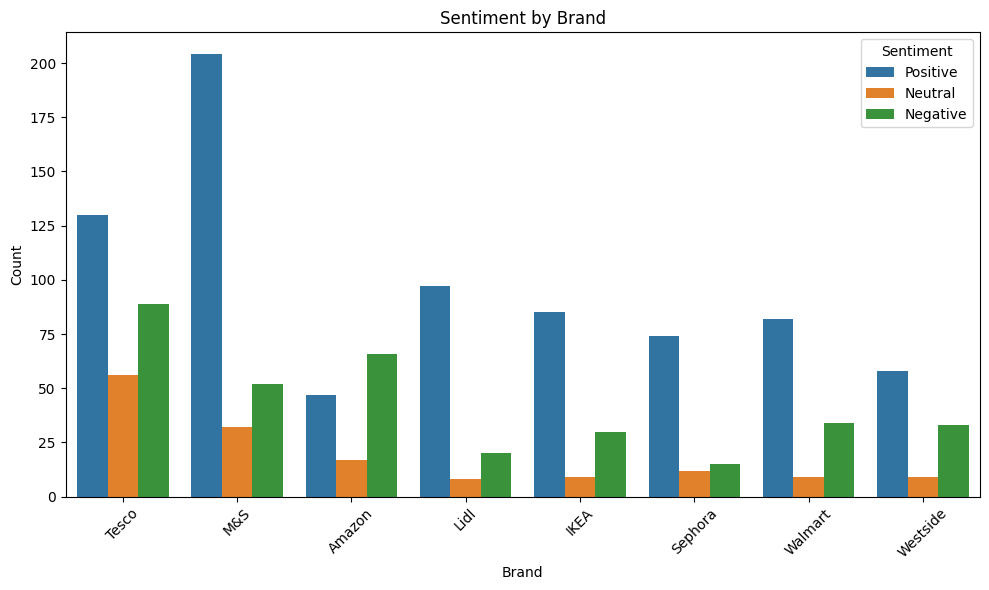

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=data, x="Brand", hue="Sentiment", hue_order=["Positive", "Neutral", "Negative"])
plt.title("Sentiment by Brand")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sentiment_by_brand.png", dpi=300)
plt.show()

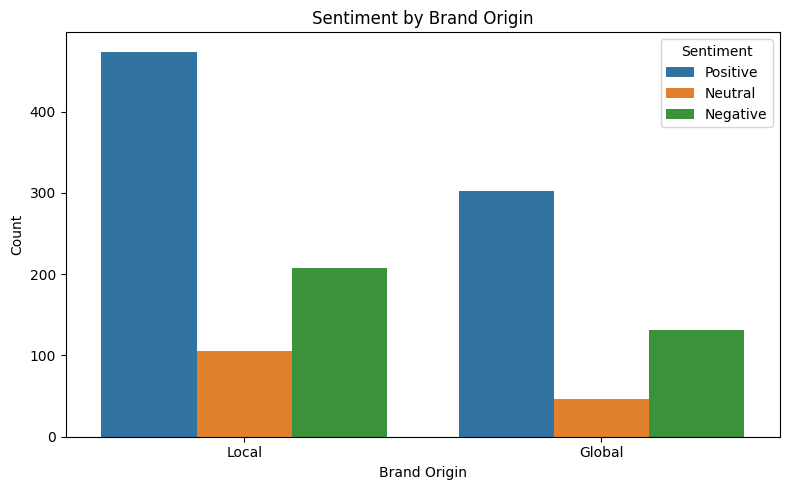

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=data, x="Origin", hue="Sentiment", hue_order=["Positive", "Neutral", "Negative"])
plt.title("Sentiment by Brand Origin")
plt.xlabel("Brand Origin")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("sentiment_by_origin.png", dpi=300)
plt.show()

In [ ]:
platform_summary = pd.crosstab(data["Platform"], data["Sentiment"])
print(platform_summary)

Sentiment  Negative  Neutral  Positive
Platform                              
Google          307      109       731
X                32       43        46


In [ ]:
brand_summary = pd.crosstab(data["Brand"], data["Sentiment"])
print(brand_summary)

Sentiment  Negative  Neutral  Positive
Brand                                 
Amazon           66       17        47
IKEA             30        9        85
Lidl             20        8        97
M&S              52       32       204
Sephora          15       12        74
Tesco            89       56       130
Walmart          34        9        82
Westside         33        9        58


In [ ]:
origin_summary = pd.crosstab(data["Origin"], data["Sentiment"])
print(origin_summary)

Sentiment  Negative  Neutral  Positive
Origin                                
Global          131       46       303
Local           208      106       474


In [ ]:
data.to_csv("final_sentiment_dataset.csv", index=False)
platform_summary.to_csv("platform_summary.csv")
brand_summary.to_csv("brand_summary.csv")
origin_summary.to_csv("origin_summary.csv")

In [ ]:
from google.colab import files

files.download("final_sentiment_dataset.csv")
files.download("platform_summary.csv")
files.download("brand_summary.csv")
files.download("origin_summary.csv")
files.download("overall_sentiment.png")
files.download("sentiment_by_platform.png")
files.download("sentiment_by_brand.png")
files.download("sentiment_by_origin.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(data.shape)
print(data["Platform"].value_counts(dropna=False))

(1268, 8)
Platform
Google    1147
X          121
Name: count, dtype: int64


In [ ]:
print("Final dataset shape:", data.shape)
print(data["Platform"].value_counts())
print(data["Origin"].value_counts())

Final dataset shape: (1268, 8)
Platform
Google    1147
X          121
Name: count, dtype: int64
Origin
Local     788
Global    480
Name: count, dtype: int64


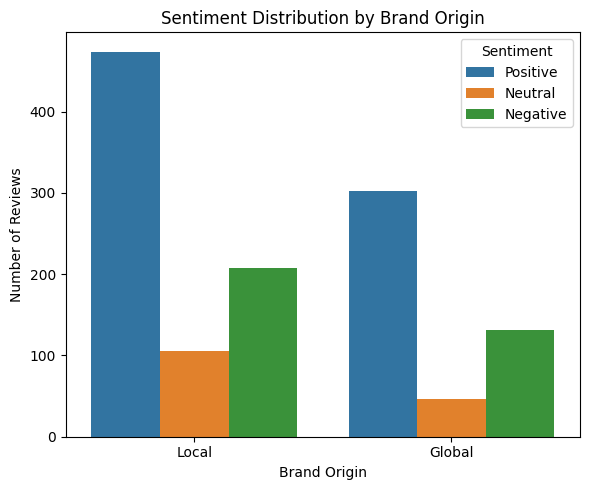

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.countplot(
    data=data,
    x="Origin",
    hue="Sentiment",
    hue_order=["Positive", "Neutral", "Negative"]
)

plt.title("Sentiment Distribution by Brand Origin", fontsize=12)
plt.xlabel("Brand Origin")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [ ]:
print(data["Origin"].unique())
print(data["Sentiment"].unique())

['Local' 'Global']
['Negative' 'Neutral' 'Positive']


In [ ]:
plt.savefig("sentiment_by_origin.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [ ]:
from collections import Counter
import re


negative_reviews = data[data["Sentiment"] == "Negative"]["Text"]


words = " ".join(negative_reviews).lower()
words = re.findall(r'\b[a-z]{3,}\b', words)


stopwords = set(["the","and","for","with","this","that","have","was","are"])
filtered_words = [w for w in words if w not in stopwords]


common_words = Counter(filtered_words).most_common(10)

print(common_words)

[('more', 232), ('they', 165), ('you', 135), ('not', 124), ('but', 94), ('review', 83), ('amazon', 78), ('had', 68), ('staff', 67), ('read', 67)]


In [ ]:
from collections import Counter
import re

negative_reviews = data[data["Sentiment"] == "Negative"]["Text"]

words = " ".join(negative_reviews).lower()
words = re.findall(r'\b[a-z]{3,}\b', words)

# Improved stopwords
stopwords = set([
    "the","and","for","with","this","that","have","was","are","but","you","they",
    "not","had","more","all","can","very","just","from","out","about","there",
    "their","your","them","what","when","how","why","will","would","could",
    "should","also","been","were","did","get","got","one","two","use","used",
    "make","made","like","really","even","still","review","read",
    "amazon","tesco","aria","label","see","store"
])

filtered_words = [w for w in words if w not in stopwords]

common_words = Counter(filtered_words).most_common(10)

print(common_words)

[('staff', 67), ('service', 59), ('customer', 57), ('experience', 46), ('delivery', 45), ('time', 38), ('because', 38), ('items', 35), ('customers', 31), ('only', 31)]


In [ ]:
import pandas as pd

theme_df = pd.DataFrame(common_words, columns=["Theme", "Frequency"])
print(theme_df)

        Theme  Frequency
0       staff         67
1     service         59
2    customer         57
3  experience         46
4    delivery         45
5        time         38
6     because         38
7       items         35
8   customers         31
9        only         31
